In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

### 1. Pos2Vec - Training Autoencoder

### Prepare Data

In [ ]:
#data = np.load("./dataset/deepchess_bitboard_positions.npy")
data = np.load("./deepchess_bitboard_positions.npy") # for google colab
train_data, temp_data = train_test_split(data, test_size=0.4, shuffle=True)
val_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=True)

# Convert data to PyTorch tensors
train_tensor = torch.tensor(train_data, dtype=torch.float32)
val_tensor = torch.tensor(val_data, dtype=torch.float32)
test_tensor = torch.tensor(test_data, dtype=torch.float32)

# Wrap them in TensorDataset
train_dataset = TensorDataset(train_tensor)
val_dataset = TensorDataset(val_tensor)
test_dataset = TensorDataset(test_tensor)

# Create DataLoaders for batching
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

#### 1a. Train layers of Pos2Vec independently

In [20]:
class Pos2Vec(nn.Module):
    def __init__(self, input_size, output_size):
        super(Pos2Vec, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, output_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(output_size, input_size),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [ ]:
# Train function with validation
def train_layer(device, model, train_data, val_data, criterion, optimizer, scheduler, epochs=200):
    model.to(device)
    best_model_state = None
    best_val_loss = float('inf')
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for data in train_data:
            data = data[0].to(device)
            optimizer.zero_grad()
            _, decoded = model(data)
            loss = criterion(decoded, data) # reconstruction loss
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_data)
        avg_val_loss = validate_model(device, model, val_data, criterion)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Save the best model state
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()

        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")
        scheduler.step()

    # After training, return the best model parameters
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses

# Validation function
def validate_model(device, model, val_data, criterion):
    model.to(device)
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for data in val_data:
            data = data[0].to(device)
            _, decoded = model(data)
            loss = criterion(decoded, data)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_data)
    return avg_val_loss

# Function to store loss curves
def store_loss_curves(start, end, train_losses, val_losses, layer_idx, loss_dict):
    loss_dict[layer_idx] = {
        "start": start,
        "end": end,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# Main function for training the stacked autoencoders with encoded data
def train_stacked_autoencoders(device, train_loader, val_loader, layer_sizes, epochs=200, learning_rate=0.005):
    current_input_size = layer_sizes[0]
    trained_models = []
    loss_data = {} # to store loss curves

    encoded_data = torch.cat([batch[0].float() for batch in train_loader], dim=0) # batch[0]: input data - labels not important for autoencoder
    encoded_val_data = torch.cat([batch[0].float() for batch in val_loader], dim=0)

    # For each layer, we will train using the encoded data from the previous layer
    for i in range(1, len(layer_sizes)):
        print(f"Training Layer {i} ({current_input_size} -> {layer_sizes[i]})")

        # Initialize model, optimizer, and loss function
        model = Pos2Vec(current_input_size, layer_sizes[i])
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss() # using MSE loss for reconstruction
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.98)

        # Create a DataLoader using the current encoded data
        encoded_train_loader = DataLoader(TensorDataset(encoded_data), batch_size=512, shuffle=True)
        encoded_val_loader = DataLoader(TensorDataset(encoded_val_data), batch_size=512, shuffle=False)

        # Train the current layer using the encoded data
        model, train_losses, val_losses = train_layer(device, model, encoded_train_loader, encoded_val_loader, criterion, optimizer, scheduler, epochs)
        store_loss_curves(current_input_size, layer_sizes[i], train_losses, val_losses, layer_idx=i, loss_dict=loss_data)

        # Freeze the trained layer
        for param in model.parameters():
            param.requires_grad = False

        # Pass the encoded features through the trained encoder of this layer
        model.to(device)
        model.eval()
        encoded_features = []
        with torch.no_grad():
            for batch in encoded_train_loader:
                batch = batch[0].float().to(device)
                encoded, _ = model(batch)
                encoded_features.append(encoded)

        # Update the encoded data for the next layer
        encoded_data = torch.cat(encoded_features, dim=0).float()
        encoded_val_data = torch.cat([model(batch[0].float().to(device))[0] for batch in encoded_val_loader], dim=0) # run model on validation data to be next batch validation data
        # Prepare the encoded data for the next layer
        current_input_size = layer_sizes[i]
        trained_models.append(model)

    return trained_models, loss_data

In [ ]:
layer_sizes = [773, 600, 400, 200, 100]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
models, loss_data = train_stacked_autoencoders(device, train_loader, val_loader, layer_sizes, epochs=200, learning_rate=0.005)

Training Layer 1 (773 -> 600)
Epoch [1/200], Train Loss: 0.2494, Validation Loss: 0.2489
Epoch [2/200], Train Loss: 0.2484, Validation Loss: 0.2479
Epoch [3/200], Train Loss: 0.2474, Validation Loss: 0.2468
Epoch [4/200], Train Loss: 0.2463, Validation Loss: 0.2458
Epoch [5/200], Train Loss: 0.2452, Validation Loss: 0.2447
Epoch [6/200], Train Loss: 0.2441, Validation Loss: 0.2435
Epoch [7/200], Train Loss: 0.2429, Validation Loss: 0.2423
Epoch [8/200], Train Loss: 0.2416, Validation Loss: 0.2409
Epoch [9/200], Train Loss: 0.2402, Validation Loss: 0.2394
Epoch [10/200], Train Loss: 0.2387, Validation Loss: 0.2379
Epoch [11/200], Train Loss: 0.2370, Validation Loss: 0.2361
Epoch [12/200], Train Loss: 0.2352, Validation Loss: 0.2342
Epoch [13/200], Train Loss: 0.2332, Validation Loss: 0.2321
Epoch [14/200], Train Loss: 0.2310, Validation Loss: 0.2299
Epoch [15/200], Train Loss: 0.2286, Validation Loss: 0.2274
Epoch [16/200], Train Loss: 0.2260, Validation Loss: 0.2247
Epoch [17/200], Tra

#### 1b. Visualise Pos2Vec training results

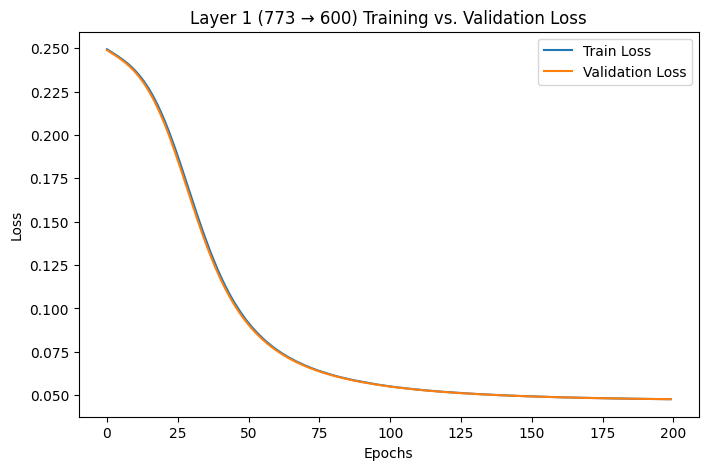

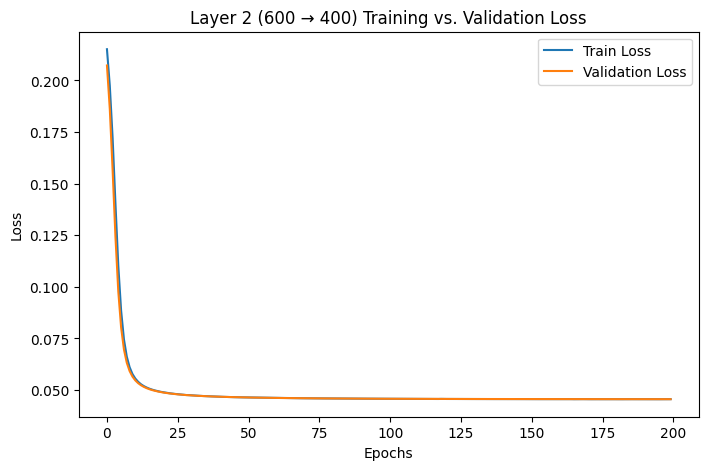

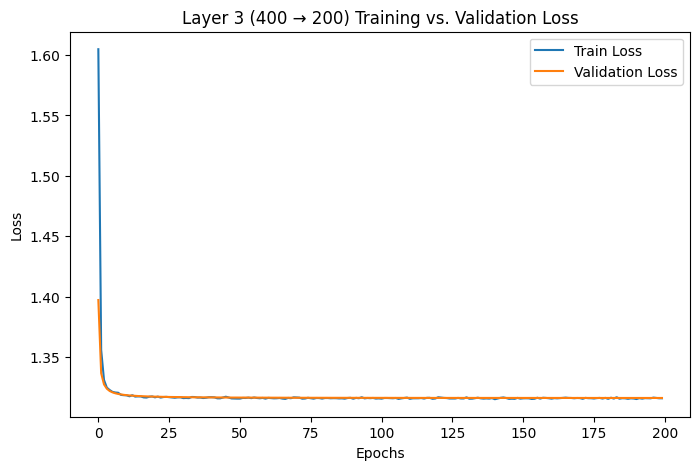

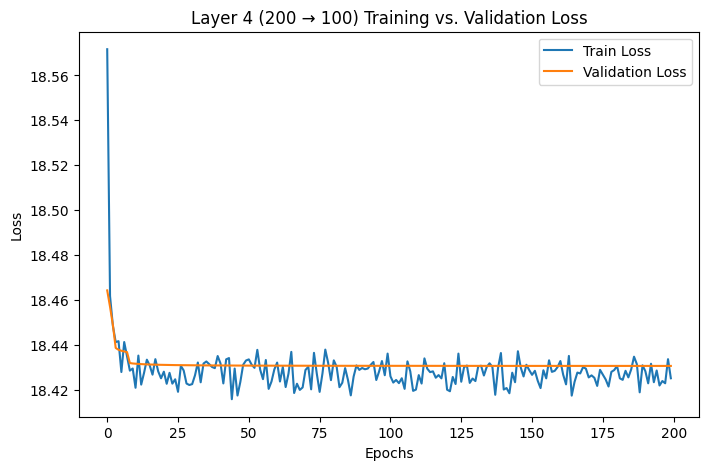

In [ ]:
def plot_stored_loss(loss_data):
    for layer_idx, data in loss_data.items():
        plt.figure(figsize=(8, 5))
        plt.plot(data["train_losses"], label='Train Loss')
        plt.plot(data["val_losses"], label='Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title(f'Layer {layer_idx} ({data["start"]} → {data["end"]}) Training vs. Validation Loss')
        plt.legend()
        plt.show()

plot_stored_loss(loss_data)

#### 1c. Save Pos2Vec

In [21]:
class FinalPos2Vec(nn.Module):
    def __init__(self, layer_sizes):
        super(FinalPos2Vec, self).__init__()
        self.encoders = nn.ModuleList([
            Pos2Vec(layer_sizes[i], layer_sizes[i+1]) for i in range(len(layer_sizes)-1)
        ])

    def forward(self, x):
        for encoder in self.encoders:
            x, _ = encoder(x) # only require encoded output
        return x # final encoded representation

In [ ]:
layer_sizes = [773, 600, 400, 200, 100]
final_pos2vec = FinalPos2Vec(layer_sizes)
# Copy weights from trained models
for i, trained_model in enumerate(models):
    final_pos2vec.encoders[i].load_state_dict(trained_model.state_dict())

torch.save(final_pos2vec.state_dict(), './Pos2Vec_autoencoder.pth')

#### 1d. Visualise Pos2Vec encoding process

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set the model to evaluation mode
final_pos2vec.eval()
final_pos2vec.to(device)

# Loop through the test data loader
for batch in test_loader:
    inputs = batch[0].float().to(device)

    # Pass through all encoder layers and print intermediate outputs
    encoded = inputs
    for i, encoder in enumerate(final_pos2vec.encoders): # iterate through layers
        encoded, _ = encoder(encoded)
        print(f"Output after layer {i+1}: {encoded.shape}") # [batch_size, dimensions]
        print(f"Layer {i+1} Stats - Min: {encoded.min().item()}, Max: {encoded.max().item()}, Mean: {encoded.mean().item()}, Std: {encoded.std().item()}")

    break

Output after layer 1: torch.Size([512, 600])
Layer 1 Stats - Min: 0.0, Max: 3.8216161727905273, Mean: 0.29451417922973633, Std: 0.42775681614875793
Output after layer 2: torch.Size([512, 400])
Layer 2 Stats - Min: 0.0, Max: 10.108430862426758, Mean: 0.7751743793487549, Std: 1.3937627077102661
Output after layer 3: torch.Size([512, 200])
Layer 3 Stats - Min: 0.0, Max: 36.464027404785156, Mean: 2.0985329151153564, Std: 4.301506042480469
Output after layer 4: torch.Size([512, 100])
Layer 4 Stats - Min: 0.0, Max: 55.684974670410156, Mean: 5.483619213104248, Std: 9.195060729980469


#### 1e. Test Pos2Vec

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

criterion = nn.MSELoss()
total_loss = 0

for model in models:
    model.eval()

# Loop through the test data loader
for batch in test_loader:
    inputs = batch[0].float().to(device)

    # Encoding process: Pass the input through all encoder layers
    encoded = inputs
    for layer in models: # loop through all layers in the models list (encoder layers)
        if hasattr(layer, 'encoder'): # encoder layer
            encoded, _ = layer(encoded) # only get the encoded output

    # Decoding process: Pass the encoded representation through all decoder layers
    decoded = encoded
    for layer in reversed(models): # loop through all layers in reverse order (decoder layers)
        if hasattr(layer, 'decoder'): # decoder layer
            decoded = layer.decoder(decoded) # decode the encoded representation

    # Calculate the reconstruction loss between the original input and the decoded output
    loss = criterion(decoded, inputs)

    # Accumulate the total loss
    total_loss += loss.item()

# Calculate the average loss
average_loss = total_loss / len(test_loader)
print(f"Average Reconstruction Loss: {average_loss}")

Average Reconstruction Loss: 0.05414247283771265


### 2. DeepChess - Training Siamese Network

### Prepare Data

In [22]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class ChessDataset(Dataset):
    def __init__(self, bitboard_file, label_file, total_train_pairs=1250000, val_test_pairs=300000):
        # Load the bitboard and label data from .npy files
        self.bitboards = np.load(bitboard_file)
        self.labels = np.load(label_file)

        # Separate W and L positions
        self.w_positions = self.bitboards[self.labels == 1]  # white win positions
        self.l_positions = self.bitboards[self.labels == 0]  # white lose positions

        # Shuffle the positions to ensure randomness
        np.random.shuffle(self.w_positions)
        np.random.shuffle(self.l_positions)

        # Reserve 150,000 W and L positions for validation (75,000 each)
        self.val_w = self.w_positions[:75000]
        self.val_l = self.l_positions[:75000]

        # Reserve 150,000 W and L positions for testing (75,000 each)
        self.test_w = self.w_positions[75000:150000]
        self.test_l = self.l_positions[75000:150000]

        # The remaining positions will be used for training
        self.train_w = self.w_positions[150000:]
        self.train_l = self.l_positions[150000:]

        # Store validation and test data as fixed sets
        self.val_data = self._generate_fixed_pairs(self.val_w, self.val_l, val_test_pairs)
        self.test_data = self._generate_fixed_pairs(self.test_w, self.test_l, val_test_pairs)

        self.total_train_pairs = total_train_pairs

    def _generate_fixed_pairs(self, w_set, l_set, num_pairs):
        pairs = set()

        while len(pairs) < num_pairs:
            w_pos = w_set[np.random.randint(len(w_set))]
            l_pos = l_set[np.random.randint(len(l_set))]
            if np.random.rand() > 0.5:
                pair = (tuple(w_pos.flatten()), tuple(l_pos.flatten()), 1)
            else:
                pair = (tuple(l_pos.flatten()), tuple(w_pos.flatten()), 0)
            pairs.add(pair)

        return [(np.array(p[0]), np.array(p[1]), np.array(p[2])) for p in pairs]

    def __len__(self):
        return self.total_train_pairs

    def __getitem__(self, idx):
        # Randomly sample positions from the training set
        w_pos = self.train_w[np.random.randint(len(self.train_w))]
        l_pos = self.train_l[np.random.randint(len(self.train_l))]

        if np.random.rand() > 0.5:
            return w_pos, l_pos, 1
        else:
            return l_pos, w_pos, 0

    def get_val_data(self):
        return self.val_data

    def get_test_data(self):
        return self.test_data


# File paths
bitboard_file = "/kaggle/input/deepchess-data/deepchess_bitboard_positions.npy"
label_file = "/kaggle/input/deepchess-data/deepchess_labels.npy"

#bitboard_file = "./dataset/deepchess_bitboard_positions.npy"
#label_file = "./dataset/deepchess_labels_mac.npy"

# Create dataset
dataset = ChessDataset(bitboard_file, label_file)

# DataLoaders
train_loader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=4)
val_loader = DataLoader(dataset.get_val_data(), batch_size=512, shuffle=False, num_workers=4)

#### 2a. Train DeepChess

In [23]:
class DeepChess(nn.Module):
    def __init__(self, pos2vec):
        super(DeepChess, self).__init__()
        self.pos2vec = pos2vec # Pos2Vec autoencoder
        self.comparator = nn.Sequential(
            nn.Linear(200, 400), # input is concatenation of two 100-d vectors
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU(),
            nn.Linear(200, 100),
            nn.ReLU(),
            nn.Linear(100, 2), # binary classification btw the two positions
        )

    def forward(self, pos_a, pos_b):
        vec_a = self.pos2vec(pos_a) # encode positions
        vec_b = self.pos2vec(pos_b)
        combined = torch.cat((vec_a, vec_b), dim=1) # concatenate feature vectors
        output = self.comparator(combined) # output "better" position

        return output

In [24]:
from tqdm import tqdm
import torch
import torch.optim as optim
import torch.nn as nn

def train_deepchess(device, model, train_loader, val_loader, epochs=100, lr=0.001):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    best_val_acc = 0.0
    best_train_acc = 0.0
    best_epoch = 0
    training_results = []
    validation_results = []

    #best_model_path = "./models/deepchess.pth"
    best_model_path = "./deepchess_final.pth"  # for google colab

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        correct_train = 0
        total_train = 0

        # Wrap the train_loader with tqdm to show the progress bar
        with tqdm(train_loader, unit="batch", desc=f"Epoch {epoch+1}/{epochs} - Training") as tepoch:
            for pos_a, pos_b, labels in tepoch:
                pos_a, pos_b, labels = pos_a.to(device).float(), pos_b.to(device).float(), labels.to(device).long()
                # Forward pass
                outputs = model(pos_a, pos_b)
                loss = criterion(outputs, labels)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_train_loss += loss.item()
                predicted = torch.argmax(outputs, dim=1)
                correct_train += (predicted == labels).sum().item()
                total_train += labels.size(0)

                # Update the tqdm progress bar with loss and accuracy
                tepoch.set_postfix(loss=total_train_loss/len(tepoch), accuracy=100*correct_train/total_train)

        scheduler.step()
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train
        avg_val_loss, val_acc = validate_deepchess(device, model, val_loader)
        
        if val_acc > best_val_acc:
            best_epoch = epoch + 1
            best_val_acc = val_acc
            best_train_acc = train_acc
            torch.save(model.state_dict(), best_model_path)

        training_results.append({"epoch": epoch + 1, "loss": avg_train_loss, "accuracy": train_acc})
        validation_results.append({"epoch": epoch + 1, "loss": avg_val_loss, "accuracy": val_acc})
        
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return training_results, validation_results, best_epoch, best_train_acc, best_val_acc

def validate_deepchess(device, model, val_loader):
    model.eval()
    total_val_loss = 0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        # Wrap the val_loader with tqdm to show the progress bar
        with tqdm(val_loader, unit="batch", desc="Validation") as tepoch:
            for pos_a, pos_b, labels in tepoch:
                pos_a, pos_b, labels = pos_a.to(device).float(), pos_b.to(device).float(), labels.to(device).long()
                outputs = model(pos_a, pos_b)
                loss = criterion(outputs, labels)
                total_val_loss += loss.item()

                predicted = torch.argmax(outputs, dim=1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

                # Update the tqdm progress bar with loss
                tepoch.set_postfix(loss=total_val_loss/len(tepoch))

    avg_val_loss = total_val_loss / len(val_loader)
    val_acc = 100 * correct / total
    return avg_val_loss, val_acc


In [ ]:
layer_sizes = [773, 600, 400, 200, 100]
pos2vec = FinalPos2Vec(layer_sizes)
#pos2vec.load_state_dict(torch.load("./models/Pos2Vec_autoencoder.pth", weights_only=True))
#pos2vec.load_state_dict(torch.load("./Pos2Vec_autoencoder.pth", weights_only=True)) # for google colab
pos2vec.load_state_dict(torch.load("/kaggle/input/pos2vec/pytorch/default/1/Pos2Vec_autoencoder.pth", weights_only=True)) # for kaggle
deepchess = DeepChess(pos2vec)
for param in deepchess.pos2vec.parameters(): # in case it was frozen previously
    param.requires_grad = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
training_results, validation_results, best_epoch, best_train_acc, best_val_acc = train_deepchess(device, deepchess, train_loader, val_loader, epochs=100, lr=0.001)

Validation: 100%|██████████| 586/586 [00:04<00:00, 122.80batch/s, loss=0.262] 


Epoch [1/100], Train Loss: 0.2266, Train Acc: 89.27%, Val Loss: 0.2623, Val Acc: 90.04%


Validation: 100%|██████████| 586/586 [00:04<00:00, 122.84batch/s, loss=0.246] 


Epoch [2/100], Train Loss: 0.0890, Train Acc: 96.00%, Val Loss: 0.2463, Val Acc: 91.76%


Validation: 100%|██████████| 586/586 [00:04<00:00, 122.03batch/s, loss=0.242] 


...

Validation: 100%|██████████| 586/586 [00:05<00:00, 110.04batch/s, loss=3.32] 


Epoch [95/100], Train Loss: 0.0093, Train Acc: 99.49%, Val Loss: 3.3171, Val Acc: 93.70%


Validation: 100%|██████████| 586/586 [00:05<00:00, 107.31batch/s, loss=3.47] 


Epoch [96/100], Train Loss: 0.0093, Train Acc: 99.50%, Val Loss: 3.4685, Val Acc: 93.67%


Epoch 97/100 - Training:  20%|██        | 498/2442 [00:06<00:17, 112.82batch/s, accuracy=99.5, loss=0.00194] 

#### 2b. Visualise DeepChess Results

In [26]:
def plot_results(training_results, validation_results, best_epoch, best_train_acc, best_val_acc):
    train_loss = [epoch_data['loss'] for epoch_data in training_results]
    val_loss = [epoch_data['loss'] for epoch_data in validation_results]
    train_acc = [epoch_data['accuracy'] for epoch_data in training_results]
    val_acc = [epoch_data['accuracy'] for epoch_data in validation_results]

    epochs = list(range(1, len(train_loss)+1))
    _, axes = plt.subplots(1, 2, figsize=(24, 6))

    # Plot Loss
    axes[0].plot(epochs, train_loss, label='Training Loss', color='blue')
    axes[0].plot(epochs, val_loss, label='Validation Loss', color='orange')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].set_xticks(range(50, len(epochs)+1, 50))

    # Plot Accuracy
    axes[1].plot(epochs, train_acc, label='Training Accuracy', color='blue')
    axes[1].plot(epochs, val_acc, label='Validation Accuracy', color='orange')
    axes[1].axvline(best_epoch, color='red', linestyle='--', label=f'Best Epoch {best_epoch}')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].set_xticks(range(50, len(epochs)+1, 50))

    # Add best accuracy text inside the plot
    acc_text = f'Best Train Acc: {best_train_acc:.2f}%\nBest Val Acc: {best_val_acc:.2f}%'
    anchored_text_acc = AnchoredText(acc_text, loc='center right', frameon=True, bbox_to_anchor=(1.2, 0.9), bbox_transform=axes[1].transAxes)
    axes[1].add_artist(anchored_text_acc)

    plt.tight_layout()
    plt.show()

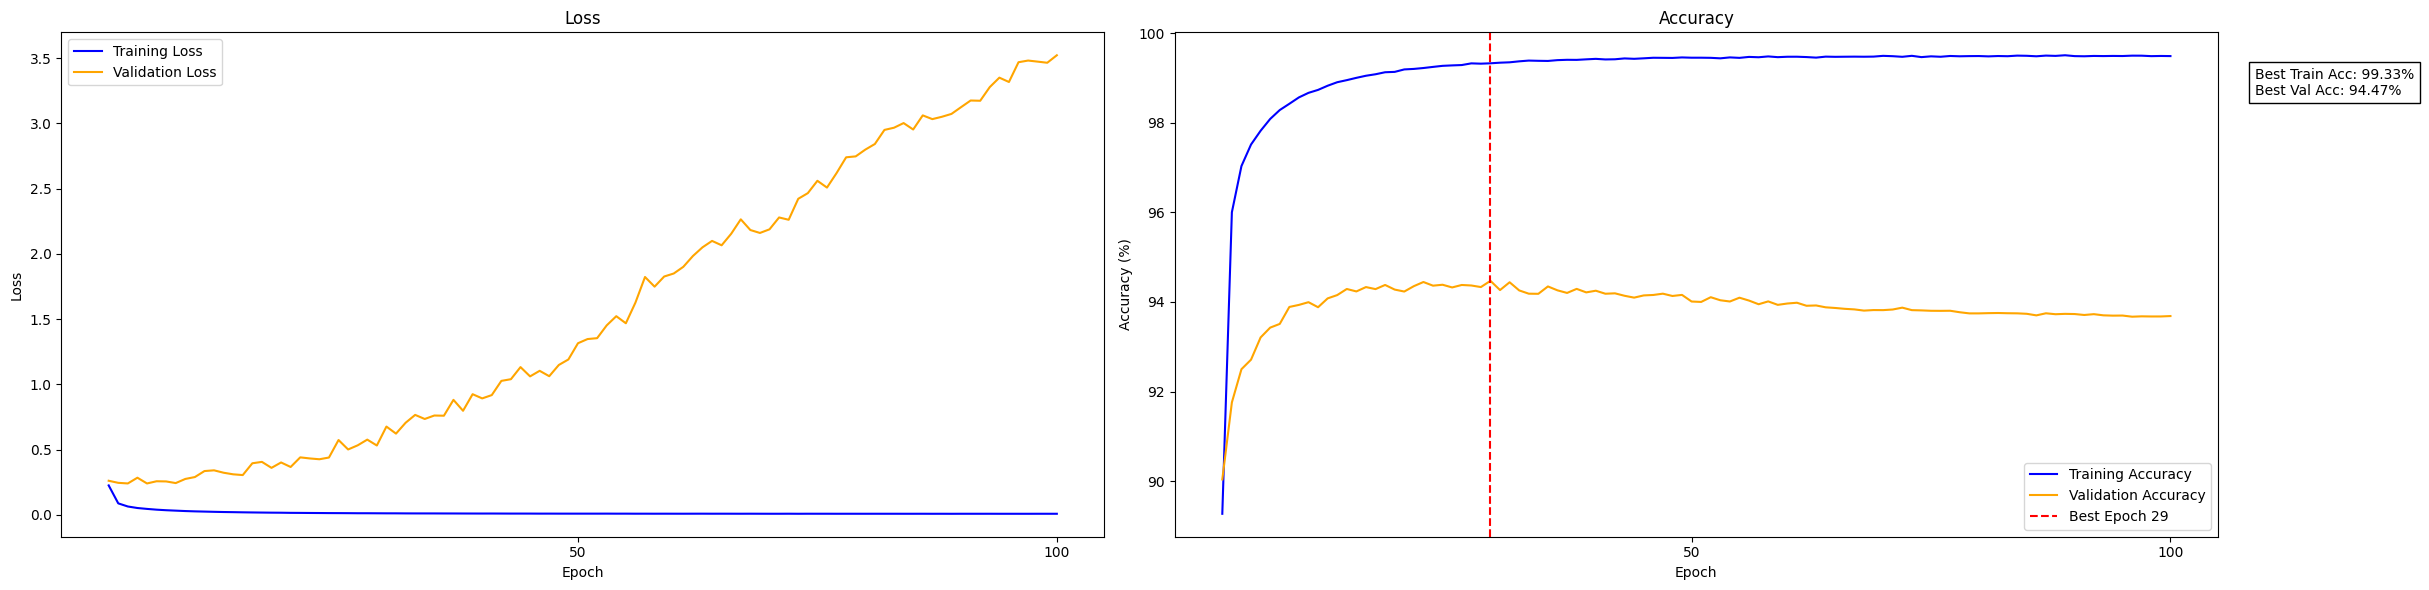

In [27]:
plot_results(training_results, validation_results, best_epoch, best_train_acc, best_val_acc)

#### 2c. Test DeepChess

In [29]:
test_data = dataset.get_test_data()
test_loader = DataLoader(test_data, batch_size=512, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

layer_sizes = [773, 600, 400, 200, 100]
pos2vec = FinalPos2Vec(layer_sizes)
#best_model_path = "./models/deepchess.pth"
best_model_path = "./deepchess_final.pth" # for google colab / kaggle
deepchess_final = DeepChess(pos2vec)
deepchess_final.load_state_dict(torch.load(best_model_path, weights_only=True))
deepchess_final.to(device)

avg_test_loss, test_acc = validate_deepchess(device, deepchess_final, test_loader)
print(f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Validation: 100%|██████████| 586/586 [00:05<00:00, 104.05batch/s, loss=0.547]

Test Loss: 0.5473, Test Acc: 94.47%
